In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

In [3]:
trades = pd.read_csv(
    r"C:\Users\tarpi\Desktop\Prime_Ass\historical_data.csv"
)

sentiment = pd.read_csv(r"C:\Users\tarpi\Desktop\Prime_Ass\fear_greed_index.csv")

In [4]:
print("Traders shape:", trades.shape)
print("sentiment shape:",sentiment.shape)

trades.head()


Traders shape: (211224, 16)
sentiment shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
print("Trades Duplicates:", trades.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trades Duplicates: 0
Sentiment Duplicates: 0


In [11]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
)

In [12]:
trades["date"] = trades["Timestamp IST"].dt.date

In [13]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

In [14]:
merged = trades.merge(
    sentiment[["date","classification","value"]],
    on="date",
    how="left"
)

In [15]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [16]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [17]:
merged.groupby("classification")["Size USD"].agg(
    ["mean","sum","count"]
)

,mean,sum,count
classification,,,
Extreme Fear,5349.731843,1.144843e+08,21400
Extreme Greed,3112.251565,1.244652e+08,39992
Fear,7816.109931,4.833248e+08,61837
Greed,5736.884375,2.885825e+08,50303
Neutral,4782.732661,1.802421e+08,37686


In [18]:
merged.groupby("classification")["Start Position"].mean()

classification
Extreme Fear      -2322.304587
Extreme Greed     19518.990812
Fear               8709.824822
Greed           -151088.546635
Neutral             144.002263
Name: Start Position, dtype: float64

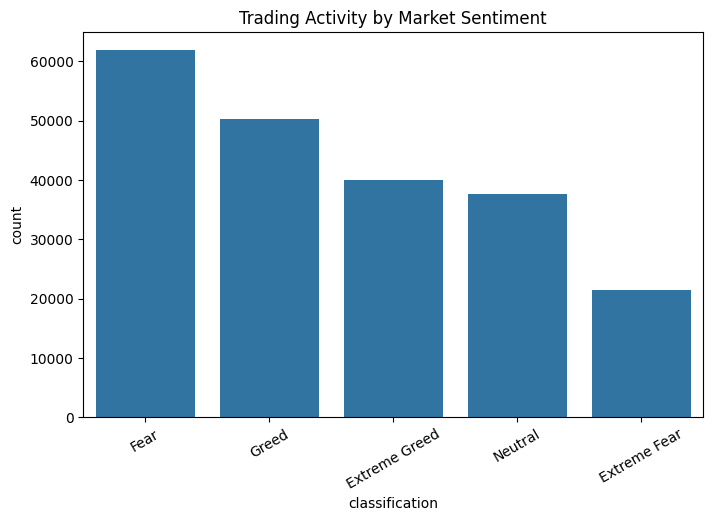

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.xticks(rotation=30)
plt.title("Trading Activity by Market Sentiment")

plt.show()

In [20]:
pnl_summary = merged.groupby(
    "classification"
)["Closed PnL"].agg(
    ["mean","median","sum","count"]
)

pnl_summary.sort_values(
    by="mean",
    ascending=False
)

,mean,median,sum,count
classification,,,,
Extreme Greed,67.892861,0.0,2.715171e+06,39992
Fear,54.290400,0.0,3.357155e+06,61837
Greed,42.743559,0.0,2.150129e+06,50303
Extreme Fear,34.537862,0.0,7.391102e+05,21400
Neutral,34.307718,0.0,1.292921e+06,37686


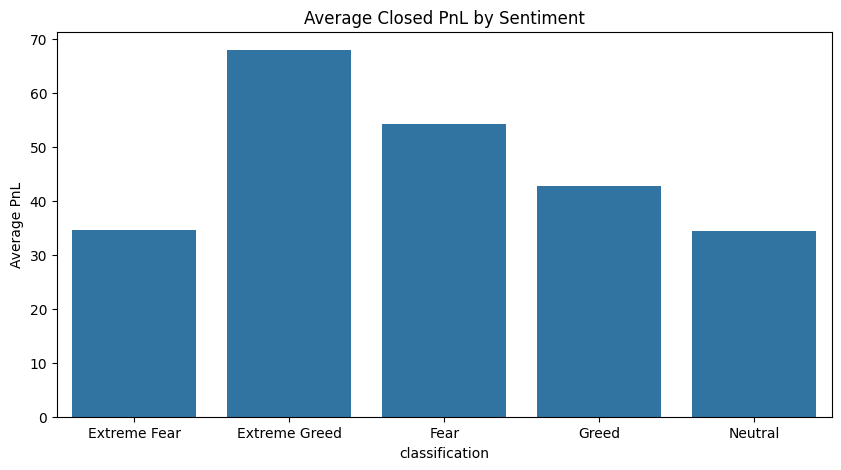

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=pnl_summary.index,
    y=pnl_summary["mean"]
)

plt.title("Average Closed PnL by Sentiment")

plt.ylabel("Average PnL")

plt.show()

In [22]:
total_profit = merged.groupby(
    "classification"
)["Closed PnL"].sum()

total_profit

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64

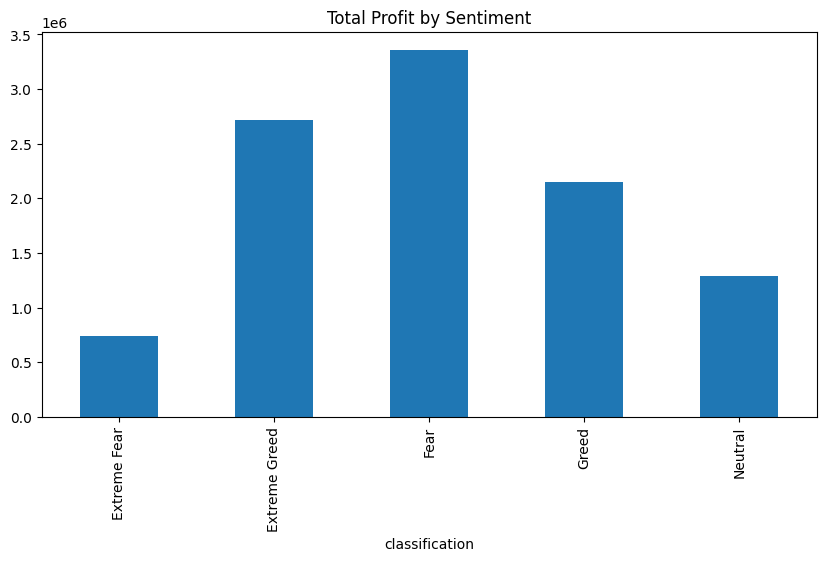

In [23]:
plt.figure(figsize=(10,5))

total_profit.plot(kind="bar")

plt.title("Total Profit by Sentiment")

plt.show()

In [24]:
merged["Win"] = merged["Closed PnL"] > 0


In [25]:
win_rate = merged.groupby(
    "classification"
)["Win"].mean()*100

win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

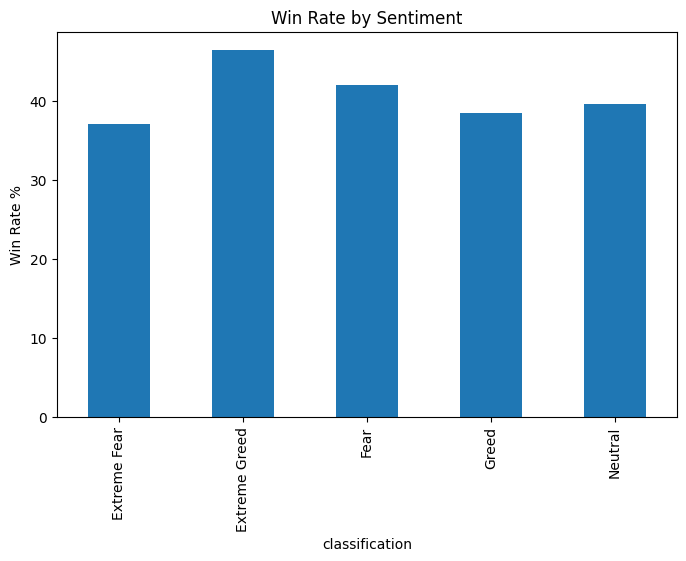

In [26]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.ylabel("Win Rate %")

plt.title("Win Rate by Sentiment")

plt.show()

In [27]:
size_analysis = merged.groupby(
    "classification"
)["Size USD"].mean()

size_analysis

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

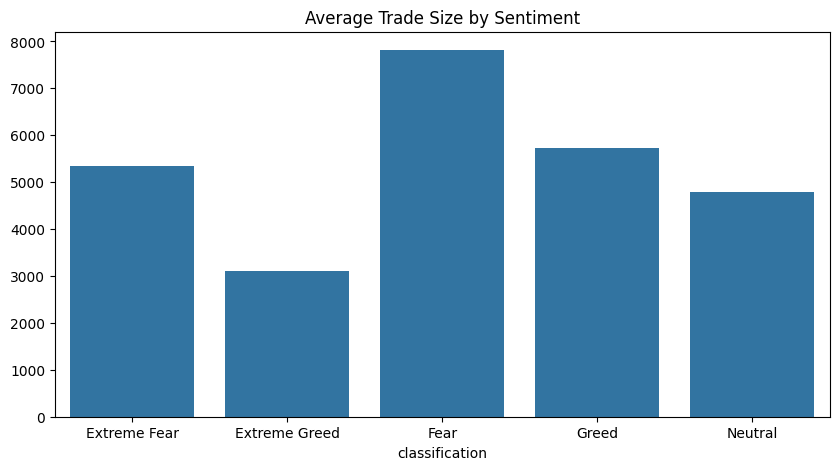

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=size_analysis.index,
    y=size_analysis.values
)

plt.title("Average Trade Size by Sentiment")

plt.show()

In [29]:
fee_analysis = merged.groupby(
    "classification"
)["Fee"].mean()

fee_analysis

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

In [30]:
side_analysis = pd.pivot_table(
    merged,
    values="Closed PnL",
    index="classification",
    columns="Side",
    aggfunc="mean"
)

side_analysis

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


In [31]:
top_traders = merged.groupby(
    "Account"
)["Closed PnL"].sum()

In [32]:
top10 = top_traders.sort_values(
    ascending=False
).head(10)

top10

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

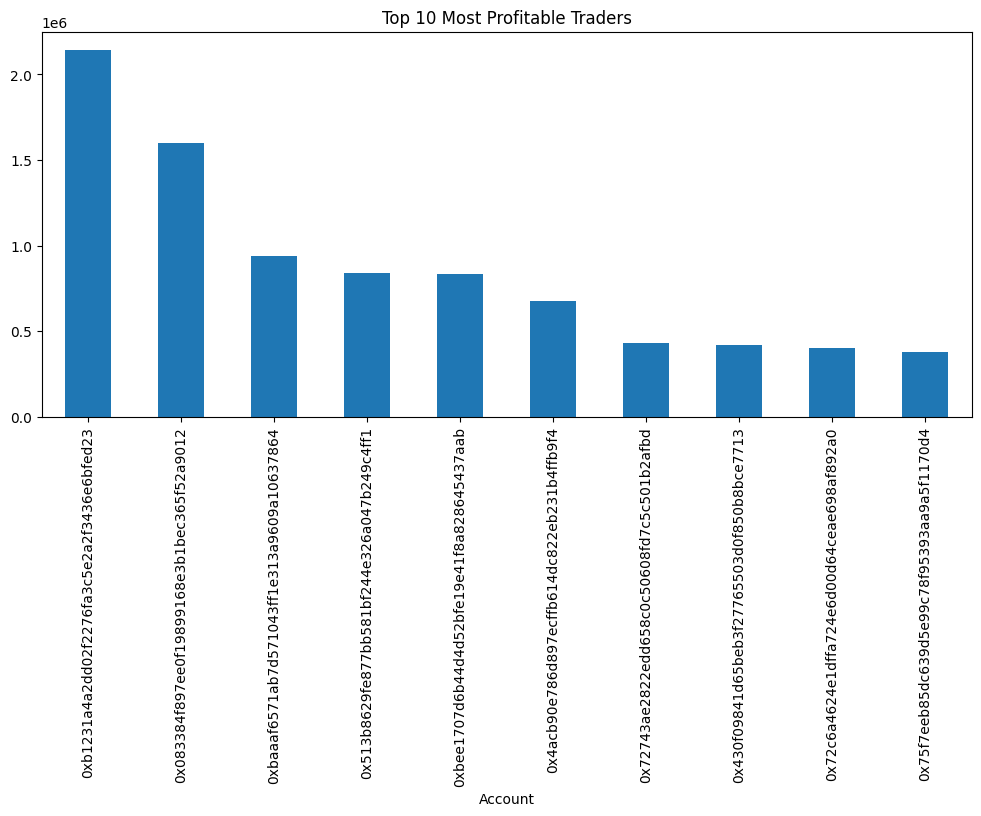

In [33]:
plt.figure(figsize=(12,5))

top10.plot(kind="bar")

plt.title("Top 10 Most Profitable Traders")

plt.show()

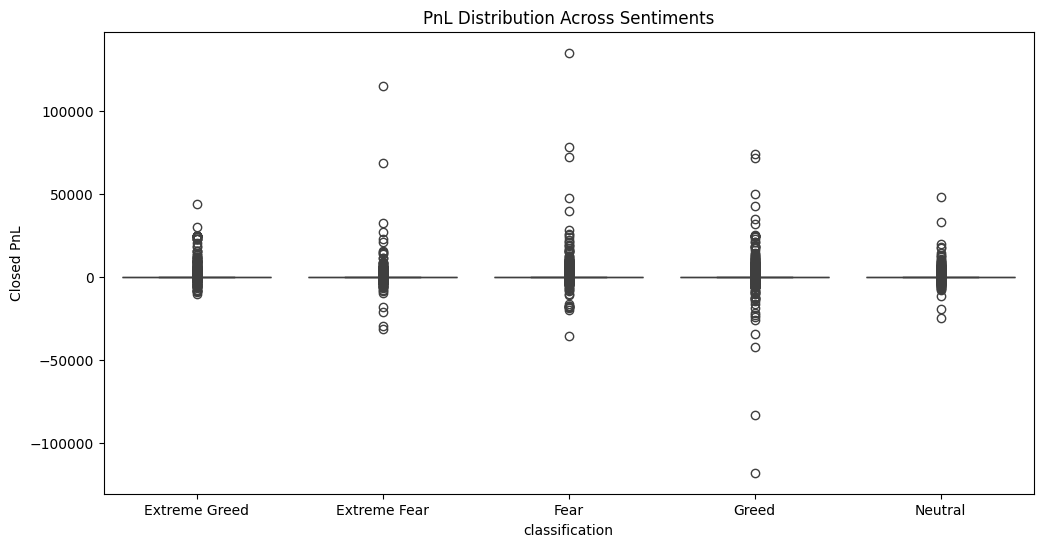

In [34]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged
)

plt.title(
    "PnL Distribution Across Sentiments"
)

plt.show()

In [35]:
pd.pivot_table(
    merged,
    values="Closed PnL",
    index="classification",
    columns="Side",
    aggfunc="mean"
)

Side,BUY,SELL
classification,,
Extreme Fear,34.114627,34.980106
Extreme Greed,10.498927,114.584643
Fear,63.927104,45.049641
Greed,25.002302,59.691091
Neutral,29.227429,39.456408


In [36]:
daily_pnl = merged.groupby(
    ["date","classification"]
)["Closed PnL"].sum().reset_index()

In [38]:
daily_pnl.head()

,date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000
